In [1]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [11]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [12]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [13]:
boston_df=pd.read_csv(boston_url)

In [14]:
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [15]:
boston_df.describe()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


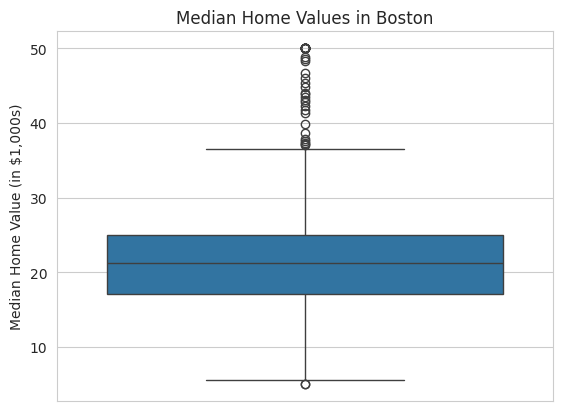

In [43]:
#Median Value BoxPlot
sns.set_style('whitegrid')
ax=sns.boxplot(y='MEDV',data=boston_df)
ax.set_ylabel('Median Home Value (in $1,000s)',fontsize=10)
ax.set_title('Median Home Values in Boston')
plt.show()

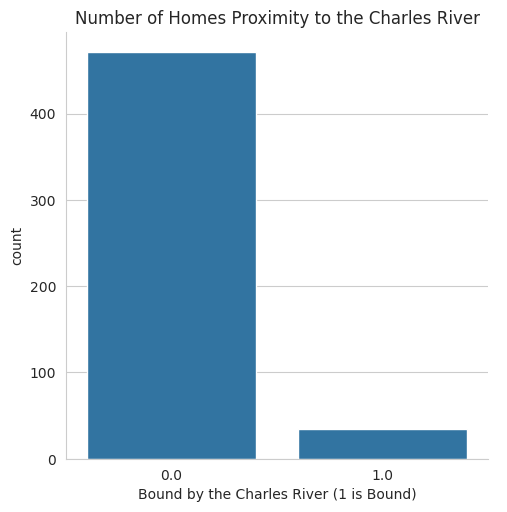

In [38]:
#Bar Plot of Charles River Dummy Variable
ax=sns.catplot(x='CHAS',kind='count',data=boston_df)
plt.xlabel('Bound by the Charles River (1 is Bound)')
plt.title('Number of Homes Proximity to the Charles River')
plt.show()

In [42]:
boston_df.loc[(boston_df['AGE']<=35),'age_group']='35 years and younger'
boston_df.loc[(boston_df['AGE']>35)&(boston_df['AGE']<70),'age_group']='between 35 and 70 years'
boston_df.loc[(boston_df['AGE']>=70),'age_group']='70 years and older'

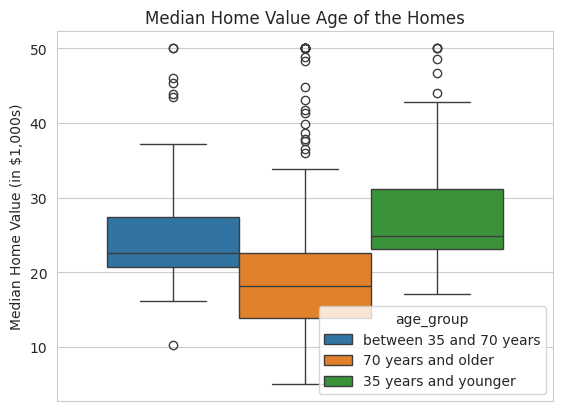

In [48]:
#Box plot of median value of homes by age (with age discretized)
ax=sns.boxplot(y='MEDV',hue='age_group',data=boston_df)
ax.set_title('Median Home Value Age of the Homes')
plt.ylabel('Median Home Value (in $1,000s)',fontsize=10)
plt.show()

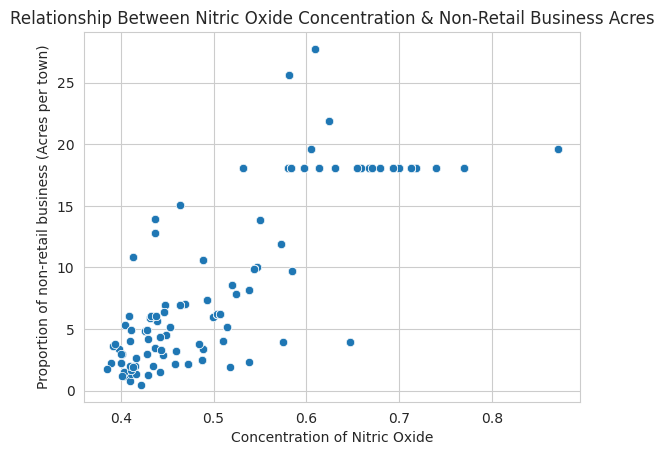

In [53]:
#Scatterplot of relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town
ax=sns.scatterplot(x='NOX',y='INDUS',data=boston_df)
plt.xlabel('Concentration of Nitric Oxide')
plt.ylabel('Proportion of non-retail business (Acres per town)')
plt.title('Relationship Between Nitric Oxide Concentration & Non-Retail Business Acres')
plt.show()
#There appears to be relationship between the two variables. When there is less nitric oxide concentration, there are more non-retail business acres per town

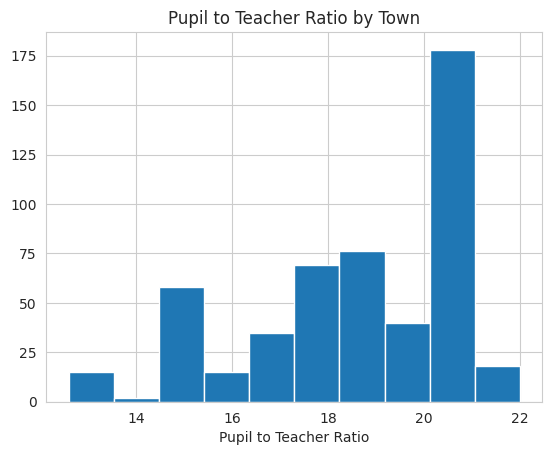

In [61]:
#Pupil to Teacher Ratio by Town
plt.hist(x='PTRATIO',data=boston_df)
plt.xlabel('Pupil to Teacher Ratio')
plt.title('Pupil to Teacher Ratio by Town')
plt.show()

In [63]:
#Question 1: Is there a significant difference in median value of houses bounded by the Charles river or not?
#Null hypothesis=There no difference in median value of houses bounded by the Charles River or Not
#alpha=0.05

scipy.stats.levene(boston_df[boston_df['CHAS']==1]['MEDV'],
                   boston_df[boston_df['CHAS']==0]['MEDV'],center='mean')

LeveneResult(statistic=8.75190489604598, pvalue=0.003238119367639829)

In [64]:
scipy.stats.ttest_ind(boston_df[boston_df['CHAS']==1]['MEDV'],
                      boston_df[boston_df['CHAS']==0]['MEDV'],equal_var=False)

TtestResult(statistic=3.113291312794837, pvalue=0.003567170098137517, df=36.876408797611994)

In [65]:
#Question 1 Result: We reject the null hypothesis; there is a difference in median home values bounded by the Charles River vs. Not

In [66]:
#Question 2: Is there a difference in Median values of houses (MEDV) for each proportion of owner occupied units built prior to 1940 (AGE)?
#Null hypothesis=There is no difference in median home values for each proportion of owner occupied units built prior to 1940
#alpha=0.05
scipy.stats.levene(boston_df[boston_df['age_group']=='35 years and younger']['MEDV'],
                   boston_df[boston_df['age_group']=='between 35 and 70 years']['MEDV'],
                   boston_df[boston_df['age_group']=='70 years and older']['MEDV'],center='mean')

LeveneResult(statistic=2.7806200293748304, pvalue=0.06295337343259205)

In [68]:
thirtyfive_younger=boston_df[boston_df['age_group']=='35 years and younger']['MEDV']
thirtyfive_seventy=boston_df[boston_df['age_group']=='between 35 and 70 years']['MEDV']
seventy_older=boston_df[boston_df['age_group']=='70 years and older']['MEDV']

In [69]:
scipy.stats.f_oneway(thirtyfive_younger,thirtyfive_seventy,seventy_older)

F_onewayResult(statistic=36.40764999196599, pvalue=1.7105011022702984e-15)

In [70]:
#Question 2 Result: We reject the null hypothesis; there is a difference in median home values for each proportion of owner occupied units built prior to 1940 (AGE)

In [71]:
#Question 3: Can we conclude that there is no relationship between Nitric oxide concentrations and proportion of non-retail business acres per town?
#Null hypothesis= there is no relationship between Nitric Oxide concentrations and proportion of non-retail business acres per town
#alpha=0.05
scipy.stats.pearsonr(boston_df['NOX'],boston_df['INDUS'])

PearsonRResult(statistic=0.7636514469209192, pvalue=7.913361061210442e-98)

In [72]:
#Question 3 result: We reject the null hypothesis; there is a relationship between Nitric Oxide concentrations and proportion of non-retail business acres per town

In [75]:
#Question 4: What is the impact of an additional weighted distance  to the five Boston employment centres on the median value of owner occupied homes?
#Null hypothesis= there is no impact on median home values by an additional weighted distance to the five Boston employment centres.
#alpha=0.05
X=boston_df['DIS']
y=boston_df['MEDV']
X=sm.add_constant(X)
model=sm.OLS(y,X).fit()
predictions=model.predict(X)
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           1.21e-08
Time:                        10:51:40   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.000      16.784      19.996
DIS            1.0916      0.188      5.795      0.000       0.722       1.462
==============================================================================
Omnibus:                      139.779   Durbin-Watson:                   0.570
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              305.104
Skew:                           1.466   Prob(JB):                     5.59e-67
Kurtosis:                       5.424   Cond. No.                         9.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [77]:
#Question 4 Result: We reject the null hypothesis and confirm there is a relationship between median home value and additional weighted distance  to the five Boston employment centres, HOWEVER it is not a fairly weak positive relationship, with the r-correlation coefficient only being ~0.25